# Jnkep minimizer fit

In [273]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu') 
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

TESS_offset = 2457000

# jax device count: 4


## 120s data

In [299]:
### Read results
d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_20s.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1345/3305227480.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [300]:
### get times, errs from the data
list_of_obs_transit_times = []
list_of_transit_time_errs = []

period_guess = [28.579657965796578, 38.35013501350135]
for j in range(2):
    list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+2]))
    list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+2]))
# index_obs_1 = np.array(d.Index[d.Planet_num==1])
index_obs_2 = np.array(d.Index[d.Planet_num==2])
index_obs_3 = np.array(d.Index[d.Planet_num==3])

tcobs = []
errorobs = []
for j in range(2):
    tcobs.append(np.array(d.Tc[d.Planet_num == j + 2]))
    errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 2]))

print(tcobs)
print(tcobs[1][0])

[array([1726.05480788, 1754.6342108 , 1783.21164545, 1811.79987609,
       1840.37515847, 1897.5350797 , 1926.11628001, 2440.54504139,
       2640.60669072, 2697.77167378, 2726.3530665 , 2812.09697059,
       2840.67291664, 2926.41892934, 3297.97086858, 3355.12996506,
       3383.71043857, 3440.87678694, 3555.19547041, 3583.77164265,
       3612.34985406, 3640.931355  ]), array([1743.55266598, 1781.90306345, 1820.26525596, 1896.96144294,
       1973.66406234, 2433.91702088, 2625.67283576, 2664.02509294,
       2702.3528068 , 2740.7175581 , 2817.41052048, 2932.46232439,
       3354.30362157, 3392.66085399, 3546.07296042, 3622.77033536,
       3661.12739362])]
1743.55266598


In [301]:
### run JaxTTV sim
t_start = 1723.  # start of integration
# t_end = 5500. # end of integration
t_end = 3670.
dt = 0.9 # integration timestep
# jttv = JaxTTV(t_start, t_end, dt, list_of_obs_transit_times, period_guess, errorobs=list_of_transit_time_errs)
jttv = JaxTTV(t_start, t_end, dt, tcobs, period_guess, errorobs=errorobs, print_info=True)

# number of transiting planets:    2
# integration starts at:           1723.00
# first transit time in data:      1726.05
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.9000 (1/31 of innermost period)



In [302]:
### set bounds for fit
param_bounds = ttv_default_parameter_bounds(jttv, emax=0.25)

### initialize p_init: p1,p2,ecosw1,ecosw2,esinw1,esinw2,tic1,tic2,lnpmass1,lnpmass2
### using best fit for run with all points
p_init = np.array([28.579657965796578, 38.35013501350135, 
                   -0.21369753, -0.18361236, 
                   -0.23016884, -0.19734158, 
                   1726.05430737, 1743.55228223, 
                   -10.97106092, -11.30491702])

### fit
popt = ttv_optim_curve_fit(jttv,param_bounds,p_init=p_init, plot=False)
# plt.show()
print(popt)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# running least squares optimization...
# objective function: 18436.44 --> 119.48 (39 data)
# elapsed time: 1.0 sec
{'period': array([28.58063687, 38.35060051]), 'ecosw': array([-0.20144563, -0.17324026]), 'esinw': array([-0.24999994, -0.214659  ]), 'tic': array([1726.05389665, 1743.55546757]), 'lnpmass': array([-10.9678498 , -11.37424738]), 'pmass': Array([1.72473889e-05, 1.14875424e-05], dtype=float64)}


In [303]:
print(1.98921496e-05* 3e5)
print(1.16917195e-05* 3e5)


5.96764488
3.50751585


/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


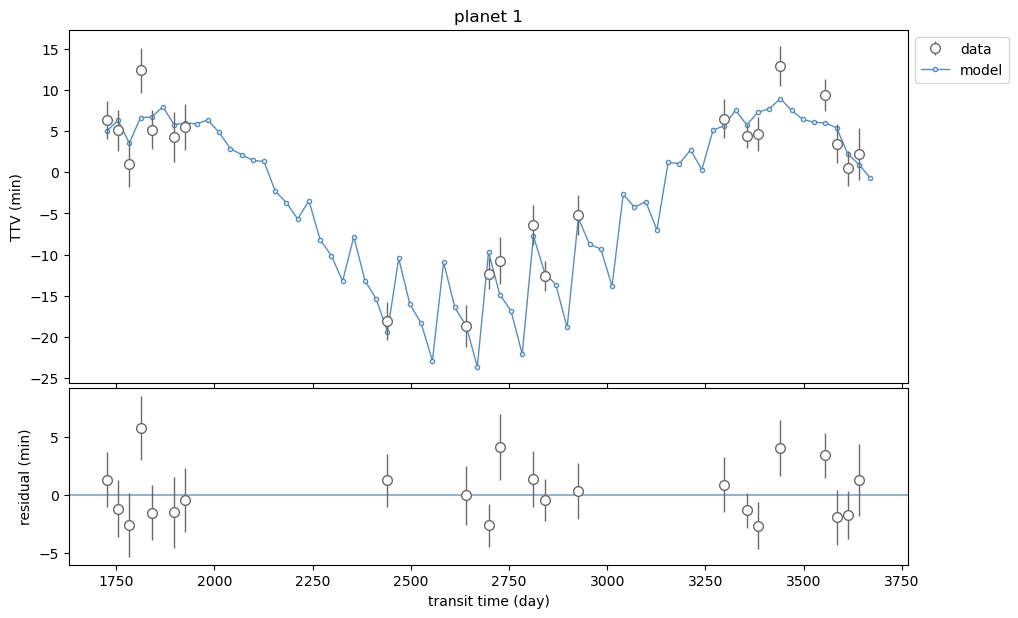

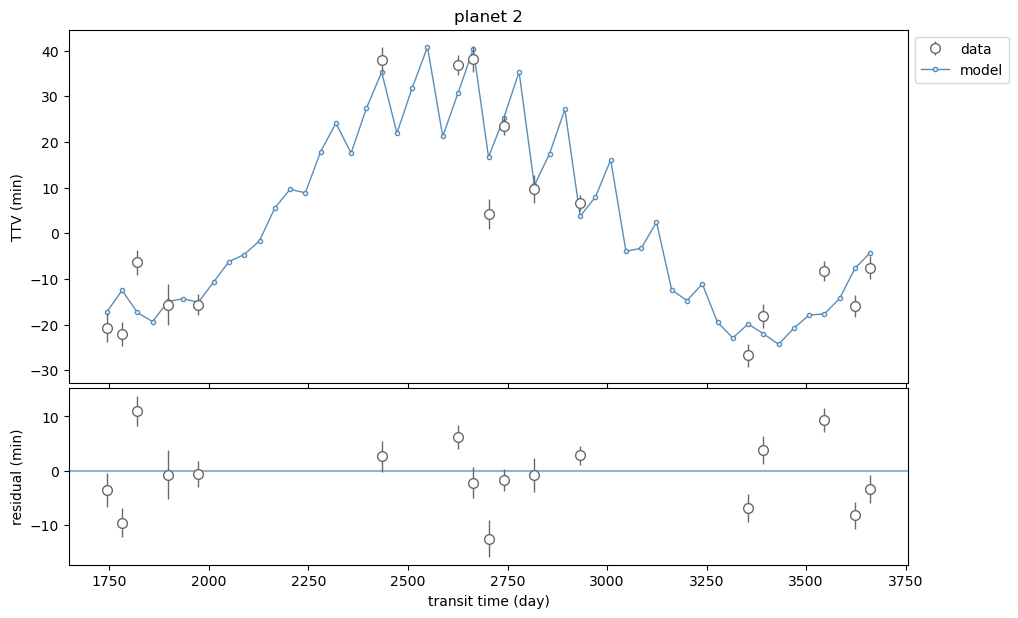

In [304]:
### plot fit
tcall = jttv.get_transit_times_all_list(popt,truncate=False)
jttv.plot_model(tcall, marker='.')
plt.show()

# fractional energy error (symplectic, dt=9.00e-01): -2.90e-09
# fractional energy error (symplectic, dt=2.86e-02): -5.83e-12
# max difference in tc: 1.07e-04 days (9.25 sec)


sample: 100%|█| 1000/1000 [00:00<00:00, 1932.59it/s, 15 steps of size 2.51e-01. 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      2.32      1.20      2.19      0.62      4.32     84.73      1.00
     lnvar      0.81      0.43      0.92      0.21      1.41     67.62      1.00

Number of divergences: 0


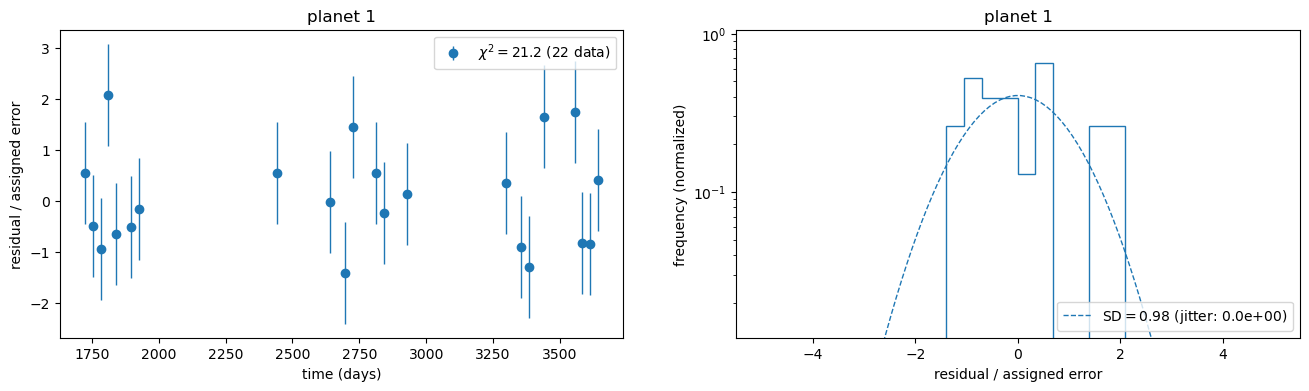

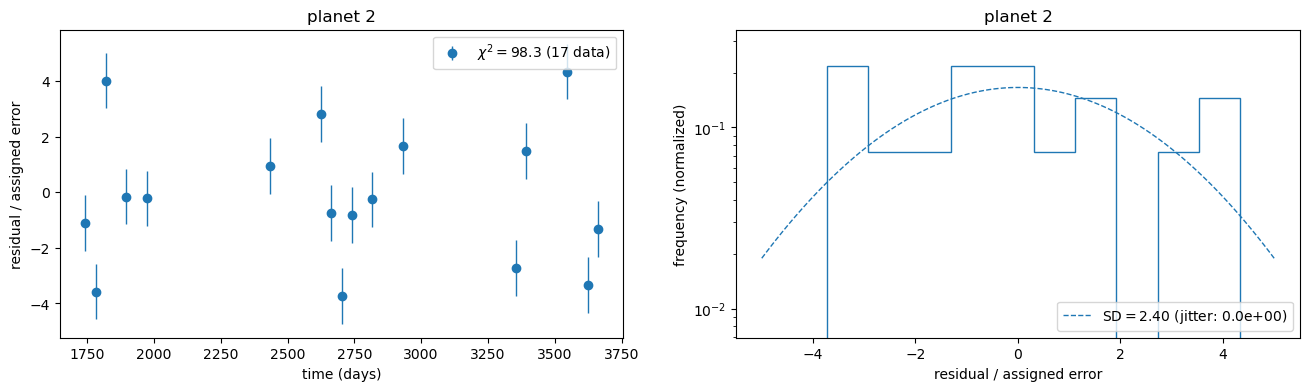

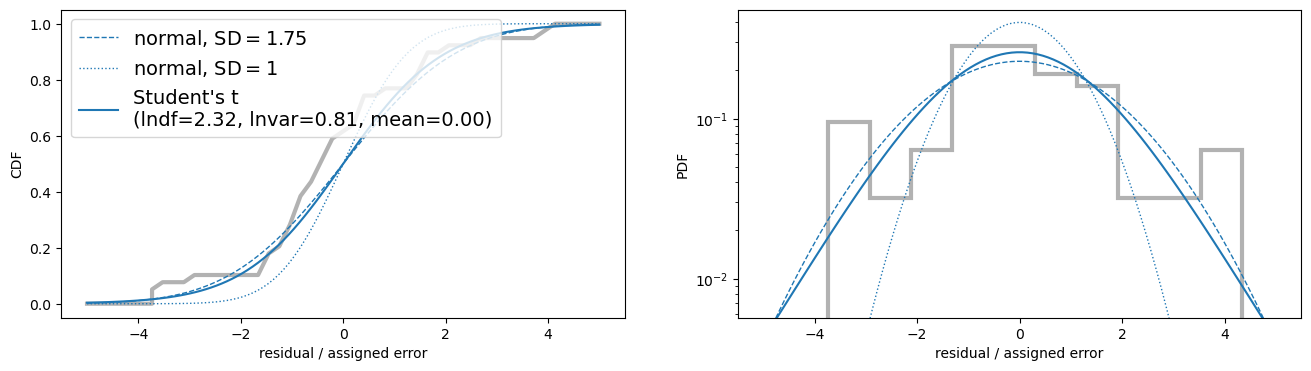

In [305]:
### check precision and residuals 
tc, _ = jttv.check_timing_precision(popt)

pdic_normal, pdic_student = jttv.check_residuals(popt)
plt.show()

## Quick and Dirty MCMC

In [257]:
def model_scaled(sample_keys, param_bounds):
    """numpyro model for scaled parameters"""
    par = {}

    # sample parameters from priors
    for key in sample_keys:
        par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds[key][0]*0, param_bounds[key][0]*0+1.))
        par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds[key][1] - param_bounds[key][0]) + param_bounds[key][0])
    if "pmass" not in sample_keys:
        par["pmass"] = numpyro.deterministic("pmass", jnp.exp(par["lnpmass"]))
    
    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    # compute transit times
    tcmodel, ediff = jttv.get_transit_times_obs(par)
    numpyro.deterministic("ediff", ediff)
    numpyro.deterministic("tcmodel", tcmodel)
    
    # likelihood
    tcerrmodel = jttv.errorobs_flatten     
    numpyro.sample("obs", dist.Normal(loc=tcmodel, scale=tcerrmodel), obs=jttv.tcobs_flatten)

In [258]:
# physical parameters to sample from
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [259]:
# scaled parameters
pdic_scaled = scale_pdic(popt, param_bounds)

In [260]:
kernel = NUTS(model_scaled, 
            init_strategy=init_to_value(values=pdic_scaled), 
            dense_mass=True,
            #regularize_mass_matrix=False # this speeds up sampling for unknown reason
            )

In [261]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [262]:
# 4hr30min on M1 mac studio
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, sample_keys, param_bounds, extra_fields=('potential_energy', 'num_steps', 'adapt_state'))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [263]:
mcmc.print_summary()


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.09      0.03      0.09      0.04      0.12      4.37      1.55
 ecosw_scaled[1]      0.15      0.03      0.15      0.11      0.18      4.25      1.57
 esinw_scaled[0]      0.00      0.00      0.00      0.00      0.00      5.00      1.96
 esinw_scaled[1]      0.07      0.00      0.07      0.07      0.07      7.06      1.23
period_scaled[0]      0.50      0.00      0.50      0.50      0.50      8.21      1.24
period_scaled[1]      0.50      0.00      0.50      0.50      0.50      5.03      1.43
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02      6.87      1.29
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01     18.36      1.17
   tic_scaled[0]      0.49      0.01      0.49      0.48      0.50    220.59      1.01
   tic_scaled[1]      0.53      0.01      0.53      0.51      0.54     84.74      1.05

Number of divergences: 0


In [264]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})


{'ecc': (600, 2), 'ecosw': (600, 2), 'ecosw_scaled': (600, 2), 'ediff': (600,), 'esinw': (600, 2), 'esinw_scaled': (600, 2), 'period': (600, 2), 'period_scaled': (600, 2), 'pmass': (600, 2), 'pmass_scaled': (600, 2), 'tcmodel': (600, 40), 'tic': (600, 2), 'tic_scaled': (600, 2)}


In [265]:
samples = mcmc.get_samples()

In [266]:
means, stds = jttv.sample_means_and_stds(samples, truncate=False)

<Figure size 1920x1440 with 0 Axes>

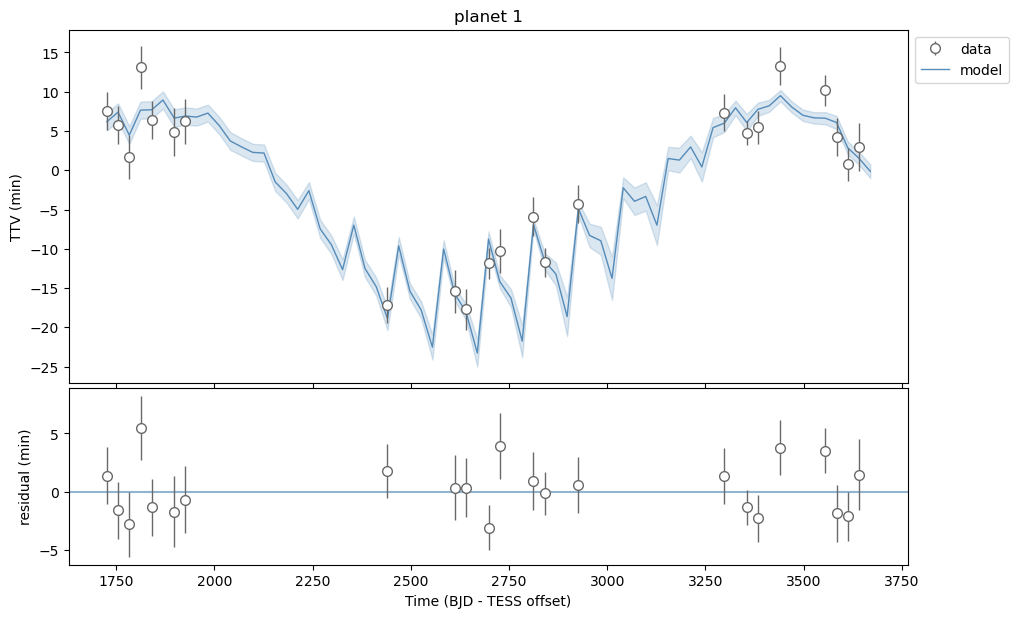

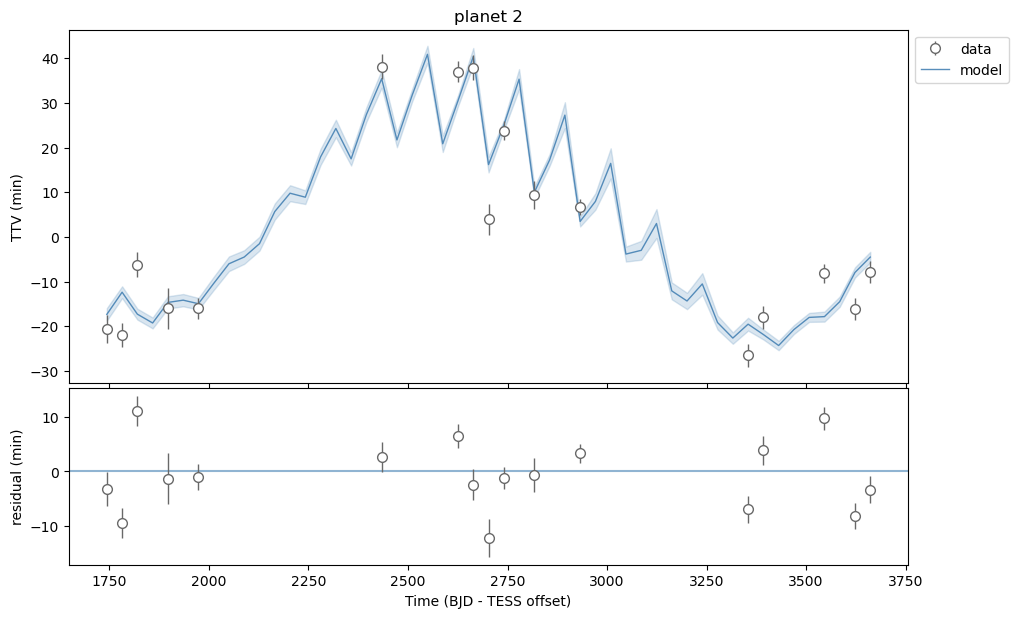

<Figure size 1920x1440 with 0 Axes>

In [267]:

jttv.plot_model(means, tcmodelunclist=stds, xlabel=f'Time (BJD - TESS offset)')
plt.figure(dpi=300) 

In [268]:
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [269]:
import arviz as az
idata = az.from_numpyro(mcmc)

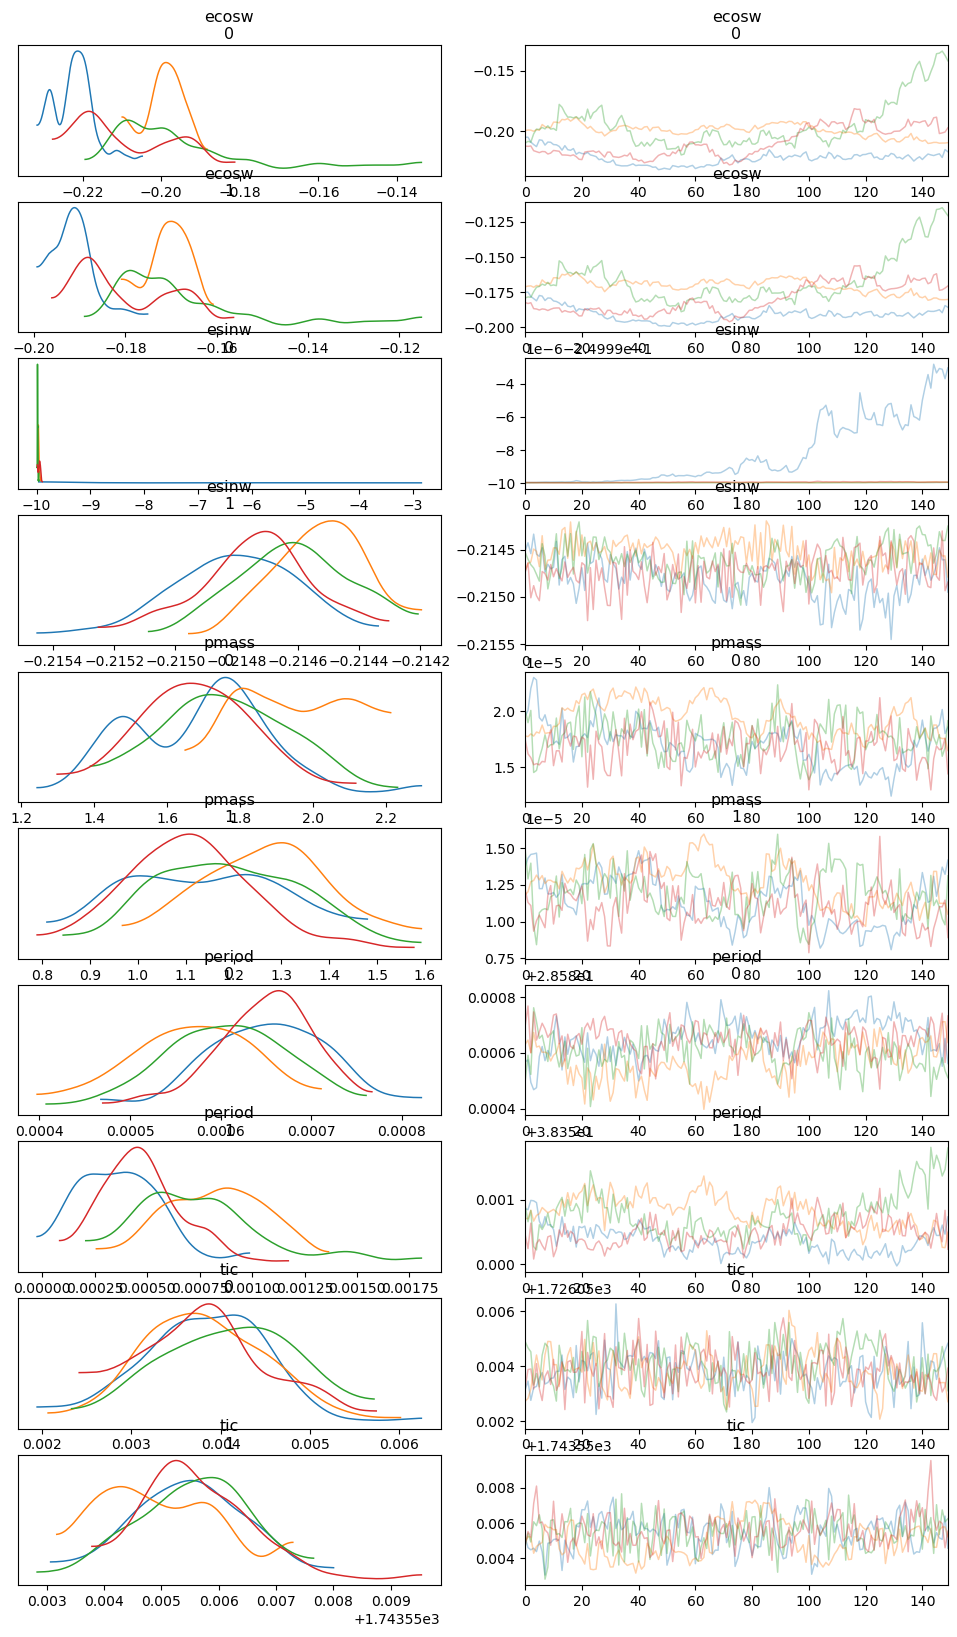

<Figure size 1920x1440 with 0 Axes>

In [270]:
# import arviz as az
# idata = az.from_numpyro(mcmc)
fig = az.plot_trace(mcmc, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

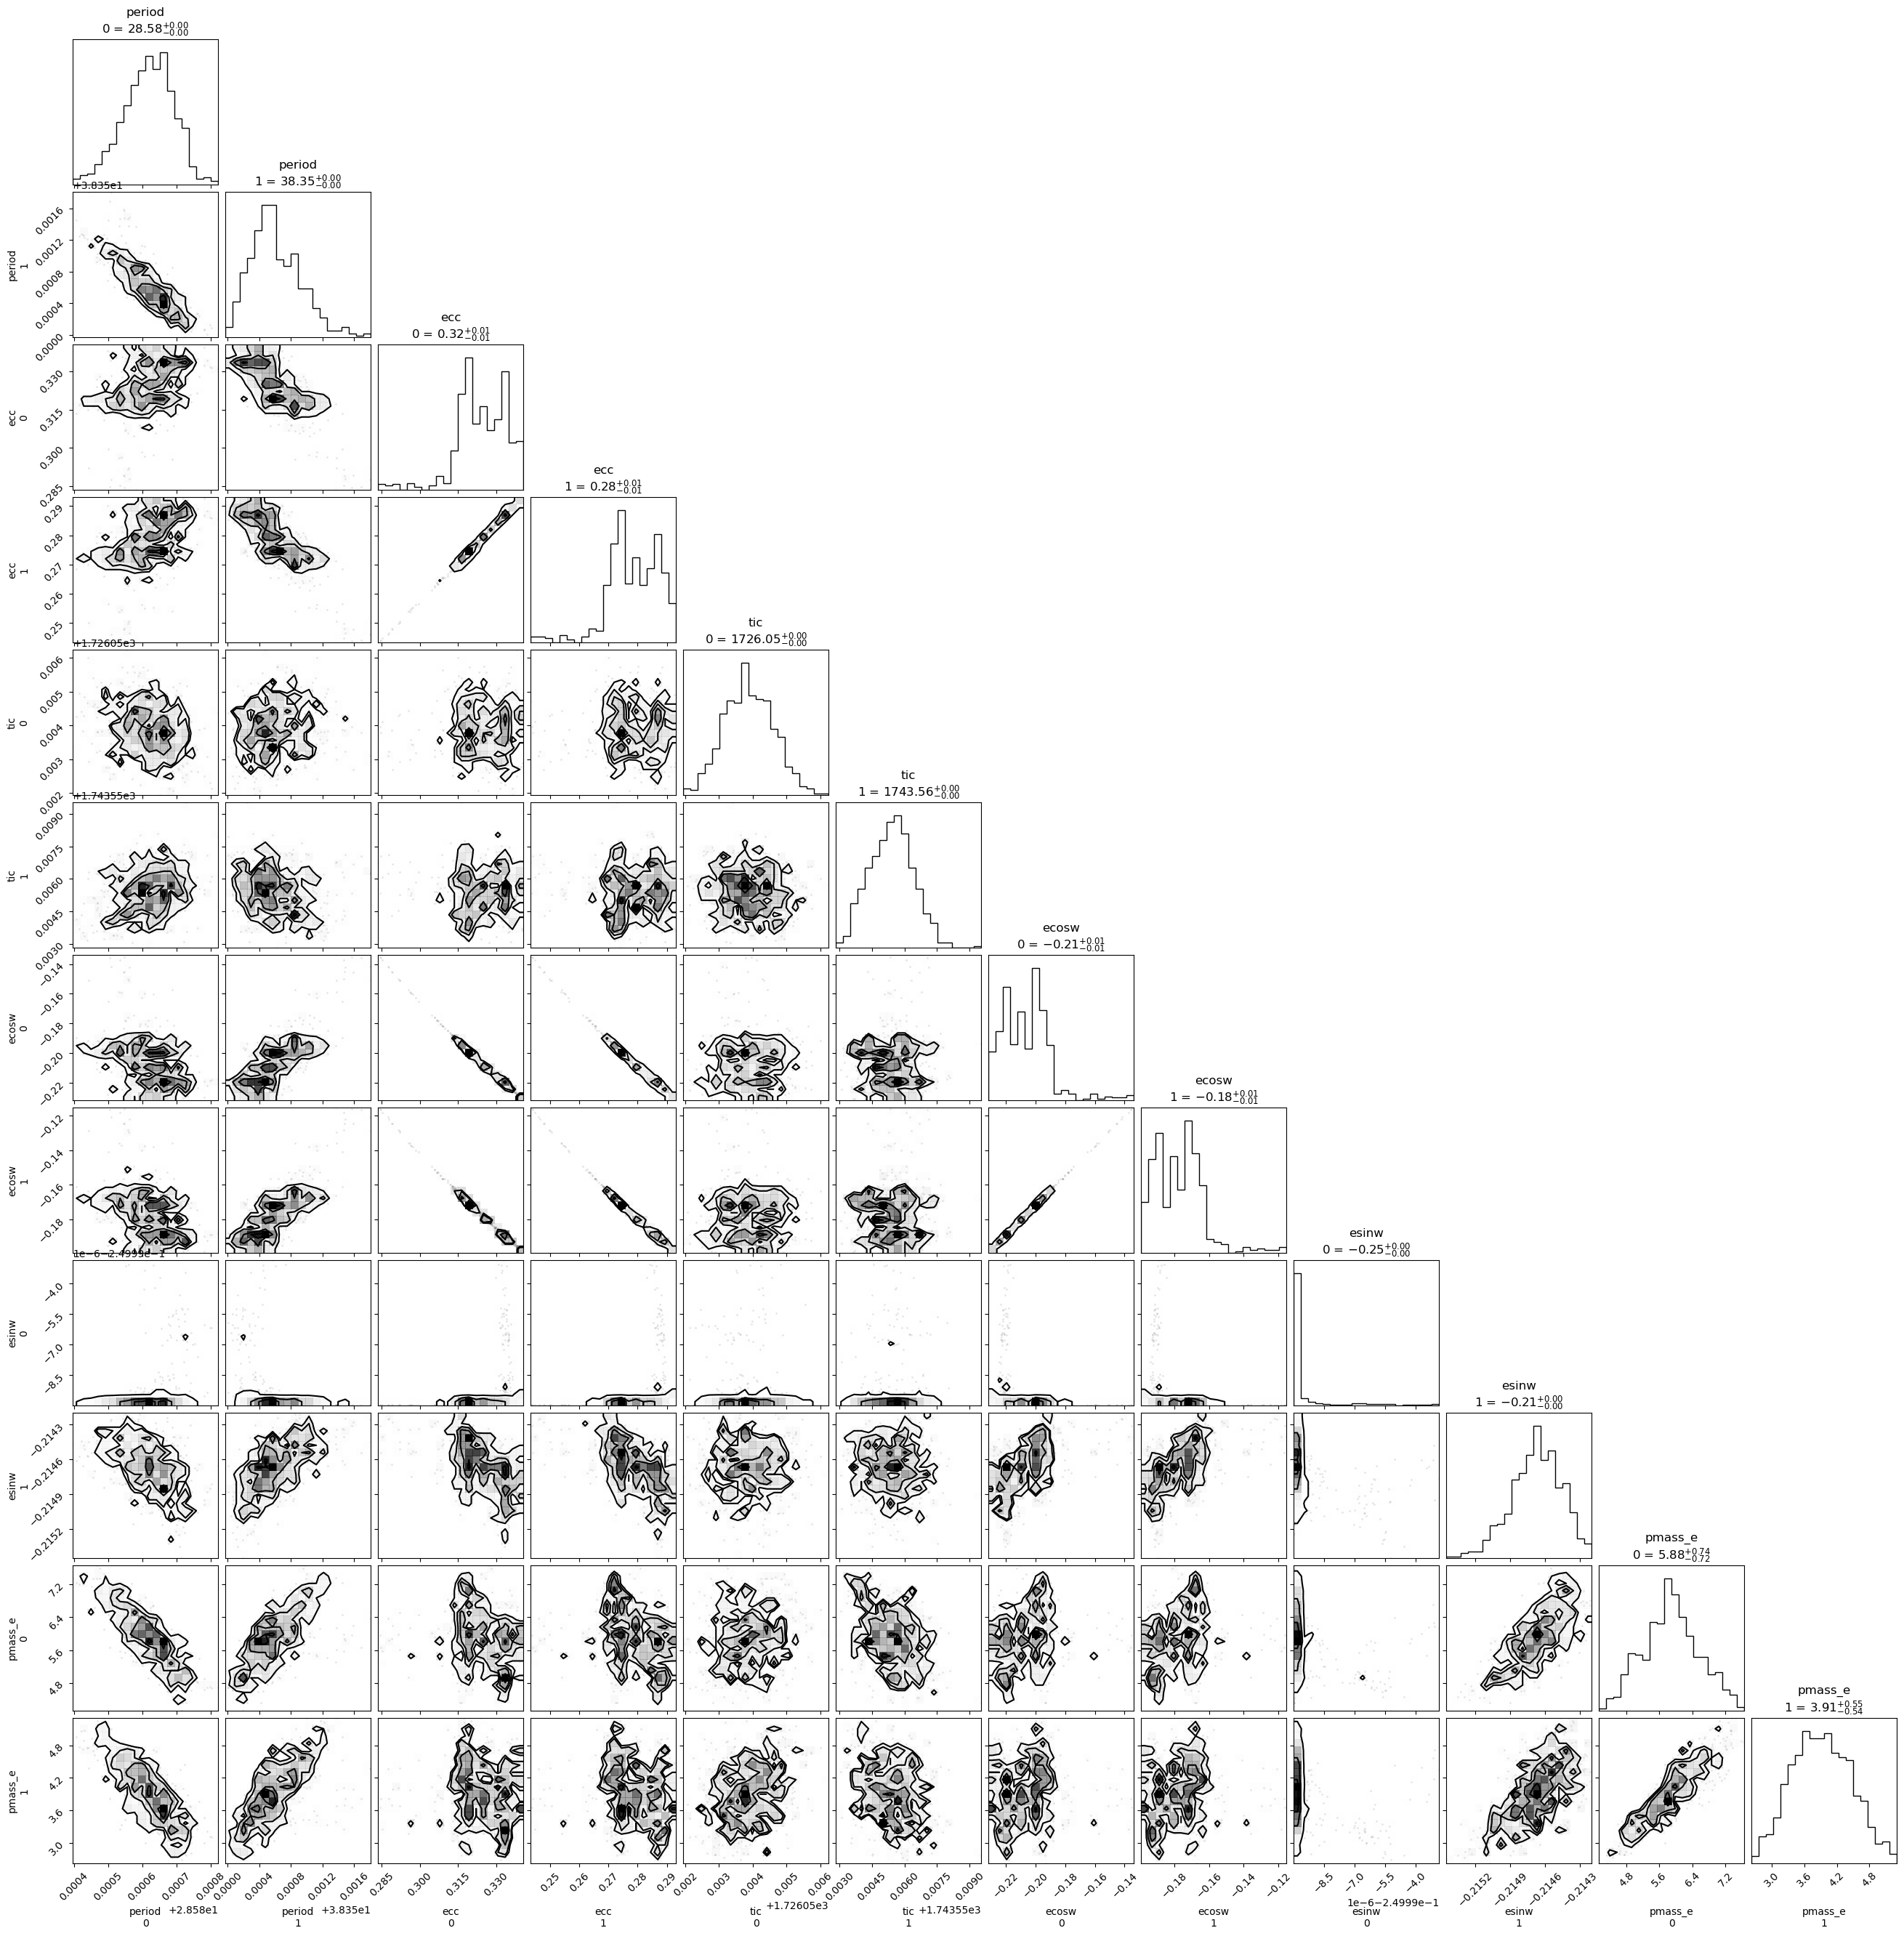

In [271]:
idata.posterior['pmass_e'] = idata.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

# Plot residuals side by side 

In [306]:
import pickle

# Load the data
with open("1339_data.pkl", "rb") as f:
    ttv_data = pickle.load(f)

# Access individual arrays
tc_lin_obs_2 = ttv_data['tc_lin_obs_2']
omc_2 = ttv_data['omc_2']
ttv_model_2 = ttv_data['ttv_model_2']
sine_residuals_2 = ttv_data["residuals_2"]
tc_err_2 = ttv_data['tc_err_2']
indices_2 = ttv_data['indices_2']

tc_lin_obs_3 = ttv_data['tc_lin_obs_3']
omc_3 = ttv_data['omc_3']
ttv_model_3 = ttv_data['ttv_model_3']
sine_residuals_3 = ttv_data["residuals_3"]
tc_err_3 = ttv_data['tc_err_3']
indices_3 = ttv_data['indices_3']

t_dense = ttv_data['t_dense']
ttv_2 = ttv_data['ttv_2']
ttv_3 = ttv_data['ttv_3']

In [307]:
t_obs_2 = tcobs[0]
t_obs_3 = tcobs[1]
t_obs_err_2 = errorobs[0]
t_obs_err_3 = errorobs[1]

In [308]:
print(tcall)

[Array([1726.05388877, 1754.63505427, 1783.2134404 , 1811.79587467,
       1840.37622327, 1868.95737036, 1897.53613909, 1926.11658746,
       1954.69679302, 1983.27742383, 2011.85665543, 2040.43557821,
       2069.01535547, 2097.59516546, 2126.17536159, 2154.75314907,
       2183.33244446, 2211.91136664, 2240.49320373, 2269.07021102,
       2297.64913834, 2326.22728099, 2354.81132144, 2383.38788865,
       2411.96662592, 2440.54417138, 2469.13063927, 2497.70704996,
       2526.28575222, 2554.8628698 , 2583.45148926, 2612.02795051,
       2640.60671605, 2669.18352977, 2697.77350975, 2726.35020334,
       2754.92912106, 2783.5057579 , 2812.09601728, 2840.67320757,
       2869.25246366, 2897.82916276, 2926.41869791, 2954.99675998,
       2983.57666591, 3012.15381044, 3040.74186372, 3069.32105761,
       3097.90182392, 3126.47972127, 3155.06571732, 3183.64590473,
       3212.22735556, 3240.80596884, 3269.38960013, 3297.97027523,
       3326.5518752 , 3355.13090707, 3383.71228689, 3412.2928

In [309]:
t_jnkep_2 = means[0]
t_jnkep_3 = means[1]
t_jnkep_err_2 = stds[0]
t_jnkep_err_3 = stds[1]

best_fit_period_2 = popt['period'][0]
best_fit_period_3 = popt['period'][1]
best_fit_tc_2 = popt['tic'][0]
best_fit_tc_3 = popt['tic'][1]

In [310]:
def ephem(p,tc,ind):
    t = tc + (p*ind)
    return t

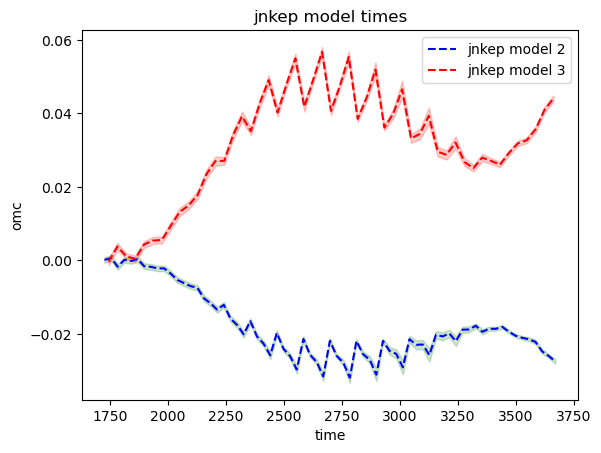

In [311]:
### plot the jnkep model
ind_jnkep_2 = np.arange(0,(len(np.array(t_jnkep_2))), 1)
ind_jnkep_3 = np.arange(0,(len(np.array(t_jnkep_3))), 1)

jnkep_ephem_time_2 = ephem(best_fit_period_2, best_fit_tc_2, ind_jnkep_2)
jnkep_ephem_time_3 = ephem(best_fit_period_3, best_fit_tc_3, ind_jnkep_3)

jnkep_omc_2 = t_jnkep_2 - jnkep_ephem_time_2
jnkep_omc_3 = t_jnkep_3 - jnkep_ephem_time_3

# plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', c='g')
# plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', c='r')

# Plotting
plt.plot(t_jnkep_2, jnkep_omc_2, label='jnkep model 2', linestyle='--', color='b')
plt.fill_between(t_jnkep_2,
                 jnkep_omc_2 - t_jnkep_err_2,
                 jnkep_omc_2 + t_jnkep_err_2,
                 color='g', alpha=0.2)

plt.plot(t_jnkep_3, jnkep_omc_3, label='jnkep model 3', linestyle='--', color='r')
plt.fill_between(t_jnkep_3,
                 jnkep_omc_3 - t_jnkep_err_3,
                 jnkep_omc_3 + t_jnkep_err_3,
                 color='r', alpha=0.2)

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

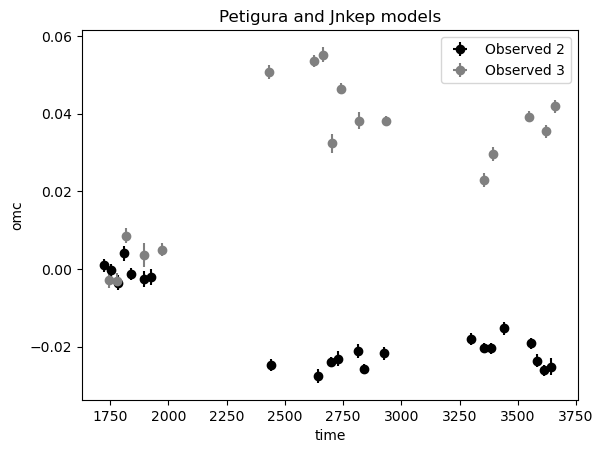

In [312]:
index_obs_2 = np.array(index_obs_2)
index_obs_3 = np.array(index_obs_3)
t_obs_2 = np.array(t_obs_2)
t_obs_3 = np.array(t_obs_3)
omc_obs_2 = t_obs_2 - ephem(best_fit_period_2, best_fit_tc_2, index_obs_2)
omc_obs_3 = t_obs_3 - ephem(best_fit_period_3, best_fit_tc_3, index_obs_3)


plt.errorbar(t_obs_2, omc_obs_2, xerr=t_obs_err_2, yerr=t_obs_err_2, marker='o', linestyle='none', label='Observed 2', c='black')
plt.errorbar(t_obs_3, omc_obs_3, xerr=t_obs_err_3, yerr=t_obs_err_3, marker='o', linestyle='none', label='Observed 3', c='grey')

plt.title('Petigura and Jnkep models')
plt.xlabel('time')
plt.ylabel('omc')
# plt.xlim(2027.88,2027.92)
# plt.xlim(1900,5500)

plt.legend()
plt.show()

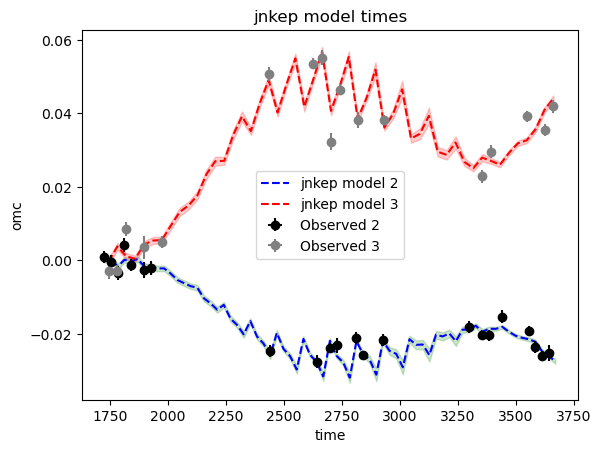

In [313]:
# Plotting
plt.plot(t_jnkep_2, jnkep_omc_2, label='jnkep model 2', linestyle='--', color='b')
plt.fill_between(t_jnkep_2,
                 jnkep_omc_2 - t_jnkep_err_2,
                 jnkep_omc_2 + t_jnkep_err_2,
                 color='g', alpha=0.2)

plt.plot(t_jnkep_3, jnkep_omc_3, label='jnkep model 3', linestyle='--', color='r')
plt.fill_between(t_jnkep_3,
                 jnkep_omc_3 - t_jnkep_err_3,
                 jnkep_omc_3 + t_jnkep_err_3,
                 color='r', alpha=0.2)
plt.errorbar(t_obs_2, omc_obs_2, xerr=t_obs_err_2, yerr=t_obs_err_2, marker='o', linestyle='none', label='Observed 2', c='black')
plt.errorbar(t_obs_3, omc_obs_3, xerr=t_obs_err_3, yerr=t_obs_err_3, marker='o', linestyle='none', label='Observed 3', c='grey')

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

In [314]:
# Interpolate model at observed points if needed
from scipy.interpolate import interp1d

# Interpolation to match observed points
model_interp_2 = interp1d(t_jnkep_2, jnkep_omc_2, bounds_error=False, fill_value="extrapolate")
model_interp_3 = interp1d(t_jnkep_3, jnkep_omc_3, bounds_error=False, fill_value="extrapolate")

residuals_2 = omc_obs_2 - model_interp_2(t_obs_2)
residuals_3 = omc_obs_3 - model_interp_3(t_obs_3)


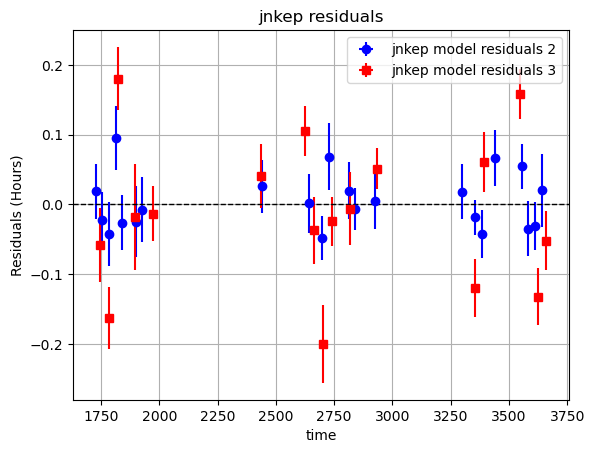

In [315]:
plt.errorbar(t_obs_2, residuals_2*24, xerr=t_obs_err_2, yerr=t_obs_err_2*24,
             marker='o', linestyle='none', label='jnkep model residuals 2', color='b')
plt.errorbar(t_obs_3, residuals_3*24, xerr=t_obs_err_3, yerr=t_obs_err_3*24,
             marker='s', linestyle='none', label='jnkep model residuals 3', color='r')

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('jnkep residuals')
plt.xlabel('time')
plt.ylabel('Residuals (Hours)')
plt.grid(True)
plt.legend()
plt.show()

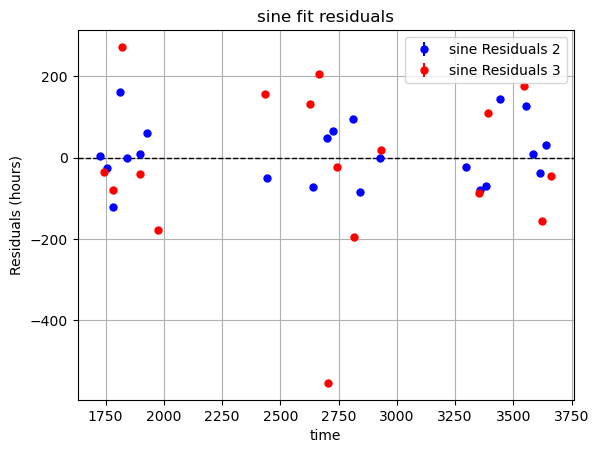

In [316]:
plt.errorbar(tc_lin_obs_2, sine_residuals_2*24, yerr=np.array(tc_err_2)*24, fmt='o',
             color='b', markersize=5, label="sine Residuals 2")
plt.errorbar(tc_lin_obs_3, sine_residuals_3*24, yerr=np.array(tc_err_3)*24, fmt='o',
             color='r', markersize=5, label="sine Residuals 3")

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('sine fit residuals')
plt.xlabel('time')
plt.ylabel('Residuals (hours)')
plt.grid(True)
plt.legend()
plt.show()


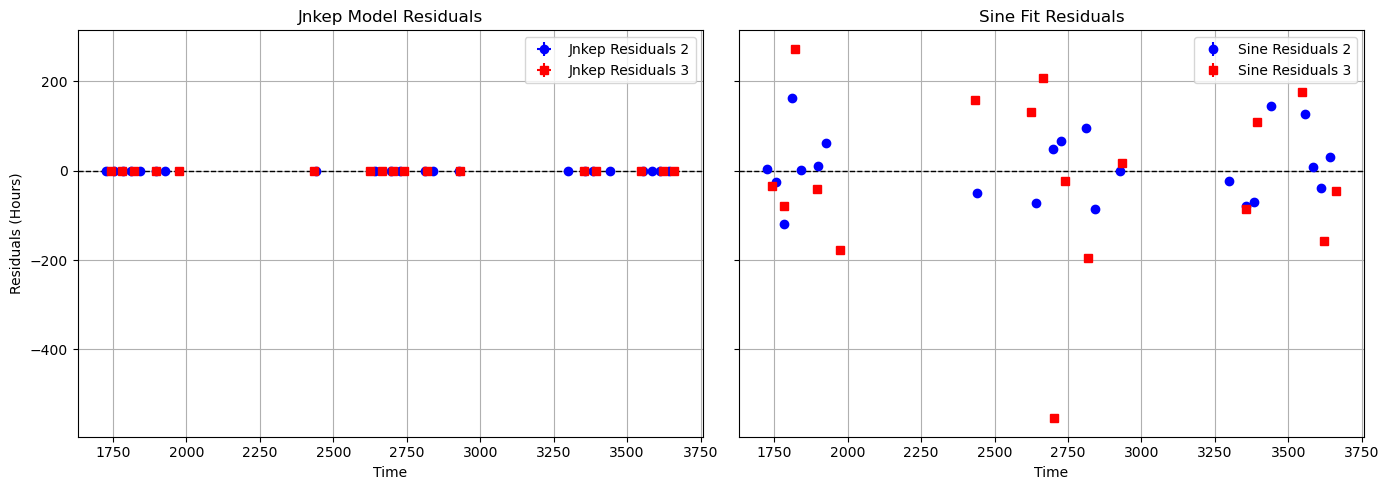

In [317]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Plot 1: jnkep residuals ---
axes[0].errorbar(t_obs_2, residuals_2*24, xerr=t_obs_err_2, yerr=t_obs_err_2*24,
                 marker='o', linestyle='none', label='Jnkep Residuals 2', color='b')
axes[0].errorbar(t_obs_3, residuals_3*24, xerr=t_obs_err_3, yerr=t_obs_err_3*24,
                 marker='s', linestyle='none', label='Jnkep Residuals 3', color='r')
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_title('Jnkep Model Residuals')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Residuals (Hours)')
axes[0].grid(True)
axes[0].legend()

# --- Plot 2: sine residuals ---
axes[1].errorbar(tc_lin_obs_2, sine_residuals_2*24, yerr=np.array(tc_err_2)*24,
                 marker='o', linestyle='none', label='Sine Residuals 2', color='b')
axes[1].errorbar(tc_lin_obs_3, sine_residuals_3*24, yerr=np.array(tc_err_3)*24,
                 marker='s', linestyle='none', label='Sine Residuals 3', color='r')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_title('Sine Fit Residuals')
axes[1].set_xlabel('Time')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [318]:
## flatten and plot models too 
# Use a linear fit (degree=1) to get slope and intercept
coeffs_2 = np.polyfit(t_jnkep_2, jnkep_omc_2, 1)
slope_2 = coeffs_2[0]
print(f'2 slope for jnkep model (from linear fit): {slope_2}')
coeffs_3 = np.polyfit(t_jnkep_3, jnkep_omc_3, 1)
slope_3 = coeffs_3[0]
print(f'3 slope for jnkep model (from linear fit): {slope_3}')

2 slope for jnkep model (from linear fit): -1.1347505699283237e-05
3 slope for jnkep model (from linear fit): 1.3920883878224059e-05


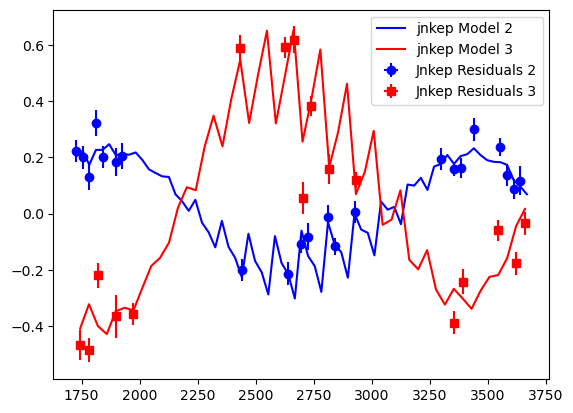

In [319]:
### Fit the linear trend for b and c (using numpy.polyfit)
def apply_trend(t, y, slope):
    # Ensure t and y are NumPy arrays
    t = np.asarray(t)
    y = np.asarray(y)
    # Remove slope, pivot about the first point
    return y - slope * (t - t[0])

flat_jnkep_2 = apply_trend(t_jnkep_2, jnkep_omc_2, slope_2)
flat_obs_2 = apply_trend(t_obs_2, (omc_obs_2), slope_2)
flat_jnkep_3 = apply_trend(t_jnkep_3, jnkep_omc_3, slope_3)
flat_obs_3 = apply_trend(t_obs_3, (omc_obs_3), slope_3)

flat_obs_2 = np.array(flat_obs_2)
t_obs_err_2 = np.array(t_obs_err_2)
flat_obs_3 = np.array(flat_obs_3)
t_obs_err_3 = np.array(t_obs_err_3)

plt.plot(t_jnkep_2, (flat_jnkep_2*24)+0.2, label='jnkep Model 2', color='b')
plt.plot(t_jnkep_3, (flat_jnkep_3*24)-0.4, label='jnkep Model 3', color='r')
plt.errorbar(t_obs_2, (flat_obs_2*24)+0.2, xerr=t_obs_err_2, yerr=t_obs_err_2*24, 
             marker='o', linestyle='none', label='Jnkep Residuals 2', color='b')
plt.errorbar(t_obs_3, (flat_obs_3*24)-0.4, xerr=t_obs_err_3, yerr=t_obs_err_3*24,
             marker='s', linestyle='none', label='Jnkep Residuals 3', color='r')
plt.legend()
plt.show()


<ErrorbarContainer object of 3 artists>

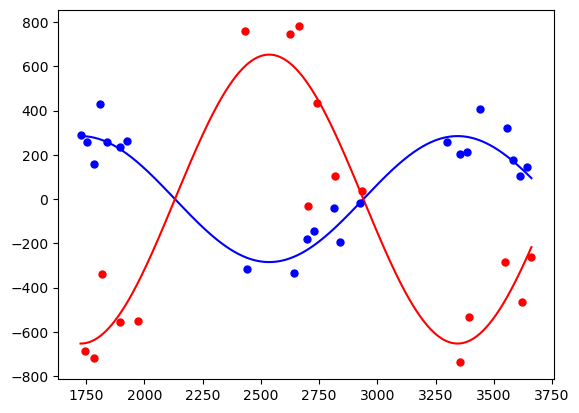

In [320]:
plt.plot(t_dense, ttv_2*24, label='sine Model 2', color='b')
plt.plot(t_dense, ttv_3*24, label='sine Model 3', color='r')
plt.errorbar(tc_lin_obs_2, omc_2*24, yerr=np.array(tc_err_2)*24, fmt='o',
             color='b', label='Observed O-C (Planet 2)', markersize=5)
plt.errorbar(tc_lin_obs_3, omc_3*24, yerr=np.array(tc_err_3)*24, fmt='o',
             color='r', label='Observed O-C (Planet 3)', markersize=5)


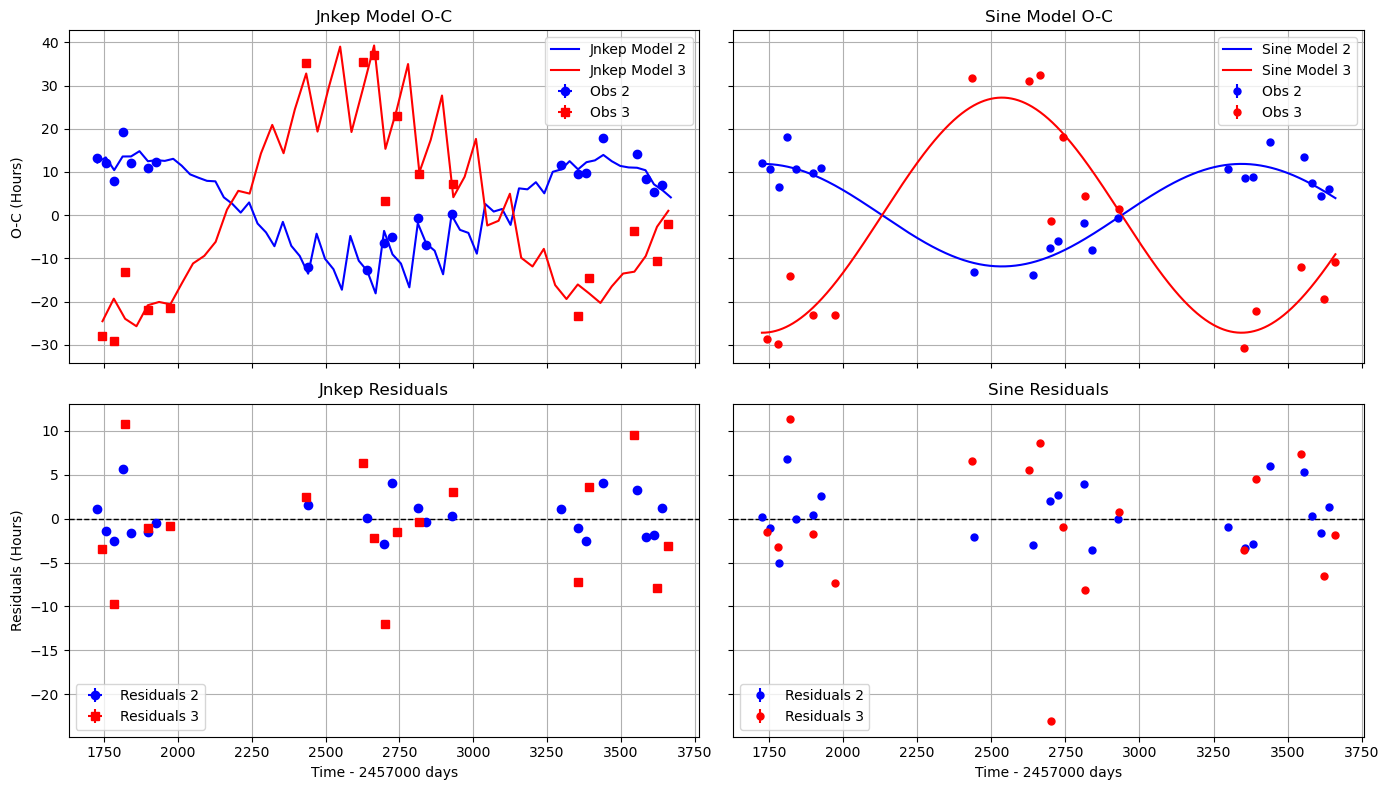

In [324]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col', sharey='row')

# --- Top Left: Jnkep Model Plot ---
axes[0, 0].plot(t_jnkep_2, (flat_jnkep_2 * 24*60) + 0.2*60, label='Jnkep Model 2', color='b')
axes[0, 0].plot(t_jnkep_3, (flat_jnkep_3 * 24*60) - 0.4*60, label='Jnkep Model 3', color='r')
axes[0, 0].errorbar(t_obs_2, (flat_obs_2 * 24*60) + 0.2*60, xerr=t_obs_err_2, yerr=t_obs_err_2 * 24,
                   marker='o', linestyle='none', color='b', label='Obs 2')
axes[0, 0].errorbar(t_obs_3, (flat_obs_3 * 24*60) - 0.4*60, xerr=t_obs_err_3, yerr=t_obs_err_3 * 24,
                   marker='s', linestyle='none', color='r', label='Obs 3')
axes[0, 0].set_title('Jnkep Model O-C')
axes[0, 0].set_ylabel('O-C (Hours)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# --- Top Right: Sine Model Plot ---
axes[0, 1].plot(t_dense, ttv_2, label='Sine Model 2', color='b')
axes[0, 1].plot(t_dense, ttv_3, label='Sine Model 3', color='r')
axes[0, 1].errorbar(tc_lin_obs_2, omc_2, yerr=np.array(tc_err_2) * 24,
                   fmt='o', color='b', markersize=5, label='Obs 2')
axes[0, 1].errorbar(tc_lin_obs_3, omc_3, yerr=np.array(tc_err_3) * 24,
                   fmt='o', color='r', markersize=5, label='Obs 3')
axes[0, 1].set_title('Sine Model O-C')
axes[0, 1].grid(True)
axes[0, 1].legend()

# --- Bottom Left: Jnkep Residuals ---
axes[1, 0].errorbar(t_obs_2, residuals_2 * 24*60, xerr=t_obs_err_2, yerr=t_obs_err_2 * 24,
                    marker='o', linestyle='none', label='Residuals 2', color='b')
axes[1, 0].errorbar(t_obs_3, residuals_3 * 24*60, xerr=t_obs_err_3, yerr=t_obs_err_3 * 24,
                    marker='s', linestyle='none', label='Residuals 3', color='r')
axes[1, 0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1, 0].set_title('Jnkep Residuals')
axes[1, 0].set_xlabel(f'Time - {TESS_offset} days')
axes[1, 0].set_ylabel('Residuals (Hours)')
axes[1, 0].grid(True)
axes[1, 0].legend()

# --- Bottom Right: Sine Residuals ---
axes[1, 1].errorbar(tc_lin_obs_2, sine_residuals_2, yerr=np.array(tc_err_2) * 24,
                    fmt='o', color='b', markersize=5, label='Residuals 2')
axes[1, 1].errorbar(tc_lin_obs_3, sine_residuals_3, yerr=np.array(tc_err_3) * 24,
                    fmt='o', color='r', markersize=5, label='Residuals 3')
axes[1, 1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1, 1].set_title('Sine Residuals')
axes[1, 1].set_xlabel(f'Time - {TESS_offset} days')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()
